# Redrob Hackathon: Data Audit and Schema Exploration

**Goal:** Understand the candidate dataset, validate the schema, inspect signal distributions, and identify early honeypot-risk patterns.

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/Redrob_Hackathon")

DATA_DIR = PROJECT_DIR / "data"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
SRC_DIR = PROJECT_DIR / "src"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"

print("Project folder ready:", PROJECT_DIR)
print("Data folder ready:", DATA_DIR)
print("Notebooks folder ready:", NOTEBOOKS_DIR)
print("Source code folder ready:", SRC_DIR)
print("Outputs folder ready:", OUTPUTS_DIR)
print("Artifacts folder ready:", ARTIFACTS_DIR)

Project folder ready: /content/drive/MyDrive/Redrob_Hackathon
Data folder ready: /content/drive/MyDrive/Redrob_Hackathon/data
Notebooks folder ready: /content/drive/MyDrive/Redrob_Hackathon/notebooks
Source code folder ready: /content/drive/MyDrive/Redrob_Hackathon/src
Outputs folder ready: /content/drive/MyDrive/Redrob_Hackathon/outputs
Artifacts folder ready: /content/drive/MyDrive/Redrob_Hackathon/artifacts


In [49]:
!pip install -q pandas numpy matplotlib seaborn tqdm python-docx

In [50]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path

In [51]:
required_files = [
    "candidates.jsonl",
    "sample_candidates.json",
    "candidate_schema.json",
    "job_description.docx",
    "redrob_signals_doc.docx",
    "submission_spec.docx",
    "sample_submission.csv",
    "validate_submission.py",
]

for file_name in required_files:
    path = DATA_DIR / file_name
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{file_name:<35} {status}")

candidates.jsonl                    FOUND
sample_candidates.json              FOUND
candidate_schema.json               FOUND
job_description.docx                FOUND
redrob_signals_doc.docx             FOUND
submission_spec.docx                FOUND
sample_submission.csv               FOUND
validate_submission.py              FOUND


In [52]:
schema_path = DATA_DIR / "candidate_schema.json"

with open(schema_path, "r", encoding="utf-8") as f:
    candidate_schema = json.load(f)

print("Schema title:", candidate_schema.get("title"))
print("Required top-level fields:", candidate_schema.get("required"))
print("\nTop-level properties:")
print(list(candidate_schema["properties"].keys()))

Schema title: Redrob Candidate Profile Schema
Required top-level fields: ['candidate_id', 'profile', 'career_history', 'education', 'skills', 'redrob_signals']

Top-level properties:
['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals']


In [53]:
profile_fields = candidate_schema["properties"]["profile"]["properties"]

print("Profile fields:\n")

for field_name, field_info in profile_fields.items():
    print(f"- {field_name}")

Profile fields:

- anonymized_name
- headline
- summary
- location
- country
- years_of_experience
- current_title
- current_company
- current_company_size
- current_industry


In [54]:
signal_fields = candidate_schema["properties"]["redrob_signals"]["properties"]

print("Redrob signal fields:\n")

for field_name in signal_fields.keys():
    print(f"- {field_name}")

Redrob signal fields:

- profile_completeness_score
- signup_date
- last_active_date
- open_to_work_flag
- profile_views_received_30d
- applications_submitted_30d
- recruiter_response_rate
- avg_response_time_hours
- skill_assessment_scores
- connection_count
- endorsements_received
- notice_period_days
- expected_salary_range_inr_lpa
- preferred_work_mode
- willing_to_relocate
- github_activity_score
- search_appearance_30d
- saved_by_recruiters_30d
- interview_completion_rate
- offer_acceptance_rate
- verified_email
- verified_phone
- linkedin_connected


In [55]:
candidate_path = DATA_DIR / "candidates.jsonl"

def load_candidate_sample(path, n=3):
    records = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))

            if len(records) == n:
                break

    return records

sample_candidates = load_candidate_sample(candidate_path, n=3)

print("Sample candidates loaded:", len(sample_candidates))
print("\nTop-level keys:")
print(sample_candidates[0].keys())

Sample candidates loaded: 3

Top-level keys:
dict_keys(['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals'])


In [56]:
from pprint import pprint
# pprint(sample_candidates[0])

In [57]:
def count_candidates(path):
    count = 0

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                count += 1

    return count

total_candidates = count_candidates(candidate_path)

print("Total candidates:", total_candidates)

Total candidates: 100000


In [58]:
def load_all_candidates(path):
    candidates = []

    with open(path, "r", encoding="utf-8") as f:
        for line in tqdm(f, desc="Loading candidates"):
            if line.strip():
                candidates.append(json.loads(line))

    return candidates

candidates = load_all_candidates(candidate_path)

print("Loaded candidates:", len(candidates))

Loading candidates: 0it [00:00, ?it/s]

Loaded candidates: 100000


In [59]:
rows = []

for candidate in tqdm(candidates, desc="Creating audit table"):
    profile = candidate.get("profile", {})
    signals = candidate.get("redrob_signals", {})

    rows.append({
        "candidate_id": candidate.get("candidate_id"),

        "years_of_experience": profile.get("years_of_experience"),
        "current_title": profile.get("current_title"),
        "current_industry": profile.get("current_industry"),
        "country": profile.get("country"),
        "location": profile.get("location"),

        "num_career_roles": len(candidate.get("career_history", [])),
        "num_skills": len(candidate.get("skills", [])),
        "num_education": len(candidate.get("education", [])),
        "num_certifications": len(candidate.get("certifications", [])),

        "profile_completeness_score": signals.get("profile_completeness_score"),
        "last_active_date": signals.get("last_active_date"),
        "open_to_work_flag": signals.get("open_to_work_flag"),
        "recruiter_response_rate": signals.get("recruiter_response_rate"),
        "avg_response_time_hours": signals.get("avg_response_time_hours"),
        "notice_period_days": signals.get("notice_period_days"),
        "github_activity_score": signals.get("github_activity_score"),
        "interview_completion_rate": signals.get("interview_completion_rate"),
        "preferred_work_mode": signals.get("preferred_work_mode"),
        "willing_to_relocate": signals.get("willing_to_relocate"),
    })

audit_df = pd.DataFrame(rows)

audit_df.head()

Creating audit table:   0%|          | 0/100000 [00:00<?, ?it/s]

,candidate_id,years_of_experience,current_title,current_industry,country,location,num_career_roles,num_skills,num_education,num_certifications,profile_completeness_score,last_active_date,open_to_work_flag,recruiter_response_rate,avg_response_time_hours,notice_period_days,github_activity_score,interview_completion_rate,preferred_work_mode,willing_to_relocate
0,CAND_0000001,6.9,Backend Engineer,IT Services,Canada,Toronto,2,17,1,0,86.9,2026-05-20,True,0.34,177.8,60,9.2,0.71,onsite,False
1,CAND_0000002,12.5,Operations Manager,IT Services,India,"Chennai, Tamil Nadu",4,9,1,0,78.7,2025-11-12,True,0.29,171.6,60,-1.0,0.62,flexible,False
2,CAND_0000003,1.1,Customer Support,IT Services,USA,Austin,1,6,2,0,31.9,2026-03-21,False,0.46,119.4,150,-1.0,0.86,hybrid,False
3,CAND_0000004,3.8,Marketing Manager,Paper Products,Australia,Sydney,3,10,2,2,28.5,2026-03-25,False,0.26,104.1,120,-1.0,0.35,onsite,True
4,CAND_0000005,11.0,Accountant,Manufacturing,India,"Gurgaon, Haryana",4,6,1,0,84.6,2025-10-01,True,0.37,116.7,30,-1.0,0.74,hybrid,True


In [60]:
print("Shape:", audit_df.shape)
print("Unique candidate IDs:", audit_df["candidate_id"].nunique())
print("Duplicate IDs:", audit_df["candidate_id"].duplicated().sum())

assert audit_df["candidate_id"].nunique() == 100000

Shape: (100000, 20)
Unique candidate IDs: 100000
Duplicate IDs: 0


In [61]:
audit_df.isnull()

,candidate_id,years_of_experience,current_title,current_industry,country,location,num_career_roles,num_skills,num_education,num_certifications,profile_completeness_score,last_active_date,open_to_work_flag,recruiter_response_rate,avg_response_time_hours,notice_period_days,github_activity_score,interview_completion_rate,preferred_work_mode,willing_to_relocate
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [62]:
audit_df[
    [
        "years_of_experience",
        "num_career_roles",
        "num_skills",
        "num_education",
        "num_certifications",
        "profile_completeness_score",
        "recruiter_response_rate",
        "avg_response_time_hours",
        "notice_period_days",
        "github_activity_score",
        "interview_completion_rate",
    ]
].describe()

,years_of_experience,num_career_roles,num_skills,num_education,num_certifications,profile_completeness_score,recruiter_response_rate,avg_response_time_hours,notice_period_days,github_activity_score,interview_completion_rate
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,7.166319,3.001710,9.60302,1.397780,0.374840,56.758180,0.436574,132.702744,87.385800,9.619230,0.619510
std,3.824551,1.522442,3.31163,0.489442,0.696046,17.274069,0.214122,75.238241,36.589628,17.761394,0.170662
min,1.000000,1.000000,5.00000,1.000000,0.000000,25.000000,0.020000,2.100000,0.000000,-1.000000,0.300000
25%,3.900000,2.000000,7.00000,1.000000,0.000000,42.200000,0.250000,68.300000,60.000000,-1.000000,0.480000
50%,6.800000,3.000000,9.00000,1.000000,0.000000,56.800000,0.440000,129.900000,90.000000,-1.000000,0.620000
75%,9.900000,4.000000,11.00000,2.000000,0.000000,71.600000,0.620000,193.300000,120.000000,16.700000,0.760000
max,16.900000,9.000000,23.00000,2.000000,3.000000,99.900000,0.950000,280.000000,150.000000,96.900000,1.000000


In [63]:
print("Top 20 current titles:\n")
display(audit_df["current_title"].value_counts().head(20))

Top 20 current titles:



,count
current_title,
Business Analyst,5833
HR Manager,5830
Mechanical Engineer,5791
Accountant,5764
Project Manager,5754
Customer Support,5750
Operations Manager,5744
Content Writer,5727
Sales Executive,5713


In [64]:
print("Top 20 locations:\n")
display(audit_df["location"].value_counts().head(20))

Top 20 locations:



,count
location,
"Bhubaneswar, Odisha",4321
"Hyderabad, Telangana",4283
"Noida, Uttar Pradesh",4283
"Jaipur, Rajasthan",4268
"Bangalore, Karnataka",4238
"Kolkata, West Bengal",4230
"Indore, Madhya Pradesh",4198
"Pune, Maharashtra",4186
"Chennai, Tamil Nadu",4164


In [65]:
print("Work mode distribution:\n")
display(audit_df["preferred_work_mode"].value_counts(dropna=False))

Work mode distribution:



,count
preferred_work_mode,
hybrid,25076
onsite,25000
flexible,25000
remote,24924


In [66]:
missing_report = (
    audit_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

missing_report.columns = ["field", "missing_percent"]

display(missing_report)

,field,missing_percent
0,candidate_id,0.0
1,years_of_experience,0.0
2,current_title,0.0
3,current_industry,0.0
4,country,0.0
5,location,0.0
6,num_career_roles,0.0
7,num_skills,0.0
8,num_education,0.0
9,num_certifications,0.0


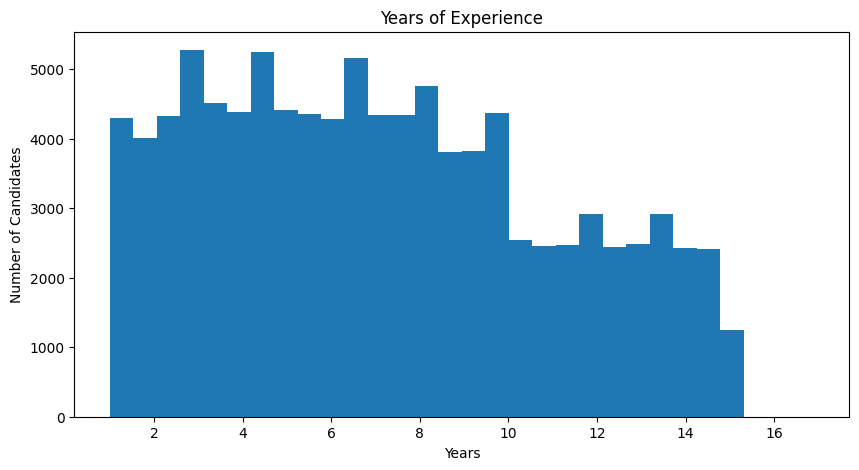

In [67]:
plt.figure(figsize=(10, 5))
plt.hist(audit_df["years_of_experience"].dropna(), bins=30)
plt.title("Years of Experience")
plt.xlabel("Years")
plt.ylabel("Number of Candidates")
plt.show()

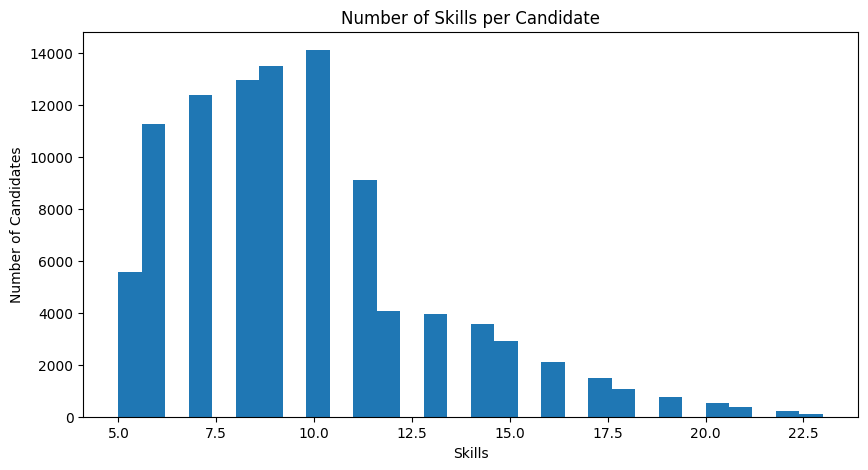

In [68]:
plt.figure(figsize=(10, 5))
plt.hist(audit_df["num_skills"].dropna(), bins=30)
plt.title("Number of Skills per Candidate")
plt.xlabel("Skills")
plt.ylabel("Number of Candidates")
plt.show()

 ## Let's Create flag to judge the profile of the candidates

 We create flags for three reasons:

Trap detection
Some candidate profiles may look good superficially but contain impossible or inconsistent patterns.
Risk scoring
Flags help us add penalties later in ranking.
Interpretability
When you later explain why a candidate was ranked up or down, flags give you a clear reason.


In [77]:
audit_df_flags = audit_df.copy()
print("Initial shape:", audit_df_flags.shape)
audit_df_flags.sample(5)

Initial shape: (100000, 20)


,candidate_id,years_of_experience,current_title,current_industry,country,location,num_career_roles,num_skills,num_education,num_certifications,profile_completeness_score,last_active_date,open_to_work_flag,recruiter_response_rate,avg_response_time_hours,notice_period_days,github_activity_score,interview_completion_rate,preferred_work_mode,willing_to_relocate
26762,CAND_0026763,10.5,Accountant,Software,India,"Bhubaneswar, Odisha",4,10,2,1,79.1,2025-11-22,False,0.42,50.2,60,-1.0,0.60,onsite,True
628,CAND_0000629,14.1,Accountant,IT Services,India,"Hyderabad, Telangana",5,6,2,0,61.0,2025-12-05,False,0.28,83.1,60,-1.0,0.70,remote,False
78676,CAND_0078677,10.4,Marketing Manager,Conglomerate,India,"Delhi, Delhi",5,6,2,0,67.8,2026-02-18,False,0.31,259.9,120,31.4,0.70,remote,False
17960,CAND_0017961,7.8,Software Engineer,Food Delivery,Australia,Sydney,3,8,1,0,70.9,2026-01-14,False,0.60,138.7,120,-1.0,0.53,flexible,True
67978,CAND_0067979,14.9,Project Manager,Software,Australia,Sydney,7,18,2,0,60.9,2025-11-04,False,0.34,278.8,150,41.7,0.66,remote,True


In [84]:
# Lets flag many skills
audit_df_flags["flag_many_skills"] = audit_df_flags["num_skills"] >= 18

print("After flag_many_skills shape:", audit_df_flags.shape)
display(audit_df_flags[["candidate_id", "num_skills", "flag_many_skills"]].sample(10))

print(audit_df_flags["flag_many_skills"].value_counts(dropna=False))

After flag_many_skills shape: (100000, 21)


,candidate_id,num_skills,flag_many_skills
86605,CAND_0086606,8,False
74341,CAND_0074342,13,False
60102,CAND_0060103,7,False
85218,CAND_0085219,20,True
19594,CAND_0019595,15,False
16289,CAND_0016290,7,False
36091,CAND_0036092,6,False
98566,CAND_0098567,13,False
86003,CAND_0086004,7,False
79118,CAND_0079119,10,False


flag_many_skills
False    96928
True      3072
Name: count, dtype: int64


In [102]:
# candidates with low experience and many roles
audit_df_flags["flag_low_experience_many_roles"] = (
    (audit_df_flags["years_of_experience"] <= 3) &
    (audit_df_flags["num_career_roles"] >= 4)
)

print("After flag_low_experience_many_roles shape:", audit_df_flags.shape)
display(audit_df_flags[["candidate_id", "years_of_experience", "num_career_roles", "flag_low_experience_many_roles"]].sample(10))
print(audit_df_flags["flag_low_experience_many_roles"].value_counts(dropna=False))

After flag_low_experience_many_roles shape: (100000, 31)


,candidate_id,years_of_experience,num_career_roles,flag_low_experience_many_roles
11146,CAND_0011147,9.0,5,False
68107,CAND_0068108,6.2,3,False
14384,CAND_0014385,4.1,2,False
61399,CAND_0061400,1.0,1,False
48662,CAND_0048663,4.3,2,False
17638,CAND_0017639,4.7,2,False
56379,CAND_0056380,5.1,2,False
31237,CAND_0031238,10.5,5,False
76686,CAND_0076687,7.4,3,False
14854,CAND_0014855,10.3,5,False


flag_low_experience_many_roles
False    99999
True         1
Name: count, dtype: int64


In [88]:
# candidate with ow profile completeness,
# incomplete profile is less trustworthy and gives fewer useful signals for ranking.
audit_df_flags["flag_bad_profile_completeness"] = audit_df_flags["profile_completeness_score"] < 35

print("After flag_bad_profile_completeness shape:", audit_df_flags.shape)
display(audit_df_flags[["candidate_id", "profile_completeness_score", "flag_bad_profile_completeness"]].head(10))
print(audit_df_flags["flag_bad_profile_completeness"].value_counts(dropna=False))

After flag_bad_profile_completeness shape: (100000, 23)


,candidate_id,profile_completeness_score,flag_bad_profile_completeness
0,CAND_0000001,86.9,False
1,CAND_0000002,78.7,False
2,CAND_0000003,31.9,True
3,CAND_0000004,28.5,True
4,CAND_0000005,84.6,False
5,CAND_0000006,29.7,True
6,CAND_0000007,74.6,False
7,CAND_0000008,63.0,False
8,CAND_0000009,39.6,False
9,CAND_0000010,81.6,False


flag_bad_profile_completeness
False    86711
True     13289
Name: count, dtype: int64


In [89]:
# low recruiter response rate
audit_df_flags["flag_very_low_response_rate"] = audit_df_flags["recruiter_response_rate"] < 0.15

print("After flag_very_low_response_rate shape:", audit_df_flags.shape)
display(audit_df_flags[["candidate_id", "recruiter_response_rate", "flag_very_low_response_rate"]].head(10))
print(audit_df_flags["flag_very_low_response_rate"].value_counts(dropna=False))

After flag_very_low_response_rate shape: (100000, 24)


,candidate_id,recruiter_response_rate,flag_very_low_response_rate
0,CAND_0000001,0.34,False
1,CAND_0000002,0.29,False
2,CAND_0000003,0.46,False
3,CAND_0000004,0.26,False
4,CAND_0000005,0.37,False
5,CAND_0000006,0.12,True
6,CAND_0000007,0.62,False
7,CAND_0000008,0.42,False
8,CAND_0000009,0.53,False
9,CAND_0000010,0.40,False


flag_very_low_response_rate
False    89575
True     10425
Name: count, dtype: int64


In [90]:
# very slow response time
# If someone takes too long to respond, the candidate may be less useful in a fast hiring cycle.
audit_df_flags["flag_very_slow_response"] = audit_df_flags["avg_response_time_hours"] > 240

print("After flag_very_slow_response shape:", audit_df_flags.shape)
display(audit_df_flags[["candidate_id", "avg_response_time_hours", "flag_very_slow_response"]].head(10))
print(audit_df_flags["flag_very_slow_response"].value_counts(dropna=False))

After flag_very_slow_response shape: (100000, 25)


,candidate_id,avg_response_time_hours,flag_very_slow_response
0,CAND_0000001,177.8,False
1,CAND_0000002,171.6,False
2,CAND_0000003,119.4,False
3,CAND_0000004,104.1,False
4,CAND_0000005,116.7,False
5,CAND_0000006,172.1,False
6,CAND_0000007,61.3,False
7,CAND_0000008,98.4,False
8,CAND_0000009,202.0,False
9,CAND_0000010,19.0,False


flag_very_slow_response
False    89908
True     10092
Name: count, dtype: int64


In [91]:
# long notice period

audit_df_flags["flag_long_notice_period"] = audit_df_flags["notice_period_days"] >= 120

print("After flag_long_notice_period shape:", audit_df_flags.shape)
display(audit_df_flags[["candidate_id", "notice_period_days", "flag_long_notice_period"]].head(10))
print(audit_df_flags["flag_long_notice_period"].value_counts(dropna=False))

After flag_long_notice_period shape: (100000, 26)


,candidate_id,notice_period_days,flag_long_notice_period
0,CAND_0000001,60,False
1,CAND_0000002,60,False
2,CAND_0000003,150,True
3,CAND_0000004,120,True
4,CAND_0000005,30,False
5,CAND_0000006,150,True
6,CAND_0000007,30,False
7,CAND_0000008,90,False
8,CAND_0000009,150,True
9,CAND_0000010,120,True


flag_long_notice_period
False    69449
True     30551
Name: count, dtype: int64


In [92]:
# missing GitHub for technical profiles
audit_df_flags["flag_no_github_for_technical_profile"] = (
    (audit_df_flags["github_activity_score"] == -1) &
    (audit_df_flags["current_title"].fillna("").str.contains(
        "engineer|developer|data|ml|ai|backend|software|full stack|frontend|machine learning",
        case=False,
        regex=True
    ))
)

print("After flag_no_github_for_technical_profile shape:", audit_df_flags.shape)
display(audit_df_flags[["candidate_id", "current_title", "github_activity_score", "flag_no_github_for_technical_profile"]].head(15))
print(audit_df_flags["flag_no_github_for_technical_profile"].value_counts(dropna=False))

After flag_no_github_for_technical_profile shape: (100000, 27)


,candidate_id,current_title,github_activity_score,flag_no_github_for_technical_profile
0,CAND_0000001,Backend Engineer,9.2,False
1,CAND_0000002,Operations Manager,-1.0,False
2,CAND_0000003,Customer Support,-1.0,False
3,CAND_0000004,Marketing Manager,-1.0,False
4,CAND_0000005,Accountant,-1.0,False
5,CAND_0000006,Business Analyst,-1.0,False
6,CAND_0000007,Civil Engineer,-1.0,True
7,CAND_0000008,Operations Manager,-1.0,False
8,CAND_0000009,Mechanical Engineer,-1.0,True
9,CAND_0000010,Data Engineer,33.7,False


flag_no_github_for_technical_profile
False    75546
True     24454
Name: count, dtype: int64


In [93]:
# low interview completion rate
audit_df_flags["flag_low_interview_completion"] = audit_df_flags["interview_completion_rate"] < 0.5

print("After flag_low_interview_completion shape:", audit_df_flags.shape)
display(audit_df_flags[["candidate_id", "interview_completion_rate", "flag_low_interview_completion"]].head(10))
print(audit_df_flags["flag_low_interview_completion"].value_counts(dropna=False))

After flag_low_interview_completion shape: (100000, 28)


,candidate_id,interview_completion_rate,flag_low_interview_completion
0,CAND_0000001,0.71,False
1,CAND_0000002,0.62,False
2,CAND_0000003,0.86,False
3,CAND_0000004,0.35,True
4,CAND_0000005,0.74,False
5,CAND_0000006,0.57,False
6,CAND_0000007,0.47,True
7,CAND_0000008,0.74,False
8,CAND_0000009,0.54,False
9,CAND_0000010,0.53,False


flag_low_interview_completion
False    72112
True     27888
Name: count, dtype: int64


In [94]:
hard_flag_cols = [
    "flag_many_skills",
    "flag_low_experience_many_roles",
    "flag_bad_profile_completeness",
    "flag_very_low_response_rate",
    "flag_very_slow_response",
]

In [95]:
soft_flag_cols = [
    "flag_long_notice_period",
    "flag_no_github_for_technical_profile",
    "flag_low_interview_completion",
]

In [97]:
audit_df_flags["hard_risk_count"] = audit_df_flags[hard_flag_cols].sum(axis=1)
audit_df_flags["soft_risk_count"] = audit_df_flags[soft_flag_cols].sum(axis=1)
audit_df_flags["total_risk_score"] = audit_df_flags["hard_risk_count"] * 2 + audit_df_flags["soft_risk_count"]

print("Final shape:", audit_df_flags.shape)
display(audit_df_flags[[
    "candidate_id",
    "hard_risk_count",
    "soft_risk_count",
    "total_risk_score"
]].sample(10))

print(audit_df_flags["total_risk_score"].describe())

Final shape: (100000, 31)


,candidate_id,hard_risk_count,soft_risk_count,total_risk_score
76319,CAND_0076320,0,0,0
13032,CAND_0013033,0,0,0
26649,CAND_0026650,1,0,2
81647,CAND_0081648,2,1,5
77754,CAND_0077755,0,1,1
99194,CAND_0099195,0,1,1
56914,CAND_0056915,1,2,4
9561,CAND_0009562,0,1,1
21761,CAND_0021762,1,0,2
29927,CAND_0029928,0,1,1


count    100000.00000
mean          1.56649
std           1.36997
min           0.00000
25%           1.00000
50%           1.00000
75%           2.00000
max          10.00000
Name: total_risk_score, dtype: float64


In [98]:
print(audit_df_flags["total_risk_score"].value_counts(dropna=False))

total_risk_score
1     30864
0     24420
2     22485
3     12953
4      5848
5      2341
6       828
7       211
8        41
10        5
9         4
Name: count, dtype: int64


In [99]:
print(audit_df.shape)
print(audit_df_flags.shape)

(100000, 20)
(100000, 31)


In [104]:
print("Original audit_df shape:", audit_df.shape)
print("Flagged audit_df_flags shape:", audit_df_flags.shape)

print("\nColumns added after flagging:")
new_columns = [
    column
    for column in audit_df_flags.columns
    if column not in audit_df.columns
]

pprint(new_columns)

Original audit_df shape: (100000, 20)
Flagged audit_df_flags shape: (100000, 31)

Columns added after flagging:
['flag_many_skills',
 'flag_low_experience_many_roles',
 'flag_bad_profile_completeness',
 'flag_very_low_response_rate',
 'flag_very_slow_response',
 'flag_long_notice_period',
 'flag_no_github_for_technical_profile',
 'flag_low_interview_completion',
 'hard_risk_count',
 'soft_risk_count',
 'total_risk_score']


In [105]:
risk_view = audit_df_flags.sort_values(
    by=["total_risk_score", "hard_risk_count", "soft_risk_count"],
    ascending=[False, False, False]
)

display(
    risk_view[
        [
            "candidate_id",
            "current_title",
            "years_of_experience",
            "num_career_roles",
            "num_skills",
            "profile_completeness_score",
            "recruiter_response_rate",
            "avg_response_time_hours",
            "notice_period_days",
            "github_activity_score",
            "interview_completion_rate",
            "hard_risk_count",
            "soft_risk_count",
            "total_risk_score",
        ]
    ].head(20)
)

,candidate_id,current_title,years_of_experience,num_career_roles,num_skills,profile_completeness_score,recruiter_response_rate,avg_response_time_hours,notice_period_days,github_activity_score,interview_completion_rate,hard_risk_count,soft_risk_count,total_risk_score
16174,CAND_0016175,Customer Support,10.6,4,20,34.2,0.09,252.1,150,-1.0,0.36,4,2,10
58245,CAND_0058246,Marketing Manager,4.8,2,18,33.2,0.12,271.9,150,-1.0,0.42,4,2,10
68412,CAND_0068413,Civil Engineer,3.7,2,18,34.3,0.10,261.8,120,35.3,0.49,4,2,10
79595,CAND_0079596,Civil Engineer,12.2,5,20,30.8,0.12,269.9,120,-1.0,0.78,4,2,10
91763,CAND_0091764,Project Manager,6.8,3,18,27.3,0.09,242.1,120,-1.0,0.48,4,2,10
64966,CAND_0064967,Customer Support,12.9,5,20,33.5,0.05,250.4,30,47.2,0.37,4,1,9
86539,CAND_0086540,HR Manager,7.8,3,22,27.4,0.12,262.1,120,-1.0,0.86,4,1,9
14276,CAND_0014277,Civil Engineer,11.8,5,7,25.2,0.11,260.3,150,-1.0,0.31,3,3,9
69060,CAND_0069061,Mechanical Engineer,11.7,4,6,28.5,0.13,265.9,150,-1.0,0.40,3,3,9
4470,CAND_0004471,Operations Manager,14.0,7,18,26.8,0.07,257.5,90,-1.0,0.68,4,0,8


In [106]:
candidate_lookup = {
    candidate["candidate_id"]: candidate
    for candidate in candidates
}

highest_risk_candidate_id = risk_view.iloc[0]["candidate_id"]

print("Highest-risk candidate ID:", highest_risk_candidate_id)

pprint(candidate_lookup[highest_risk_candidate_id])

Highest-risk candidate ID: CAND_0016175
{'candidate_id': 'CAND_0016175',
 'career_history': [{'company': 'Infosys',
                     'company_size': '10001+',
                     'description': 'Business analyst at a consulting firm, '
                                    'working primarily with retail and CPG '
                                    'clients. Conducted business diagnostics, '
                                    'process re-engineering work, and digital '
                                    'transformation strategy projects. Strong '
                                    'on stakeholder management, structured '
                                    'problem-solving, and the typical '
                                    'consulting toolkit (slide-craft, Excel '
                                    'modeling, executive communication). '
                                    'Recent project work involved AI-strategy '
                                    'advisory but my own tec

In [107]:
print("Risk-score distribution:")
display(
    audit_df_flags["total_risk_score"]
    .value_counts()
    .sort_index()
)

print("\nRisk-score summary:")
display(
    audit_df_flags[
        ["hard_risk_count", "soft_risk_count", "total_risk_score"]
    ].describe()
)

Risk-score distribution:


,count
total_risk_score,
0,24420
1,30864
2,22485
3,12953
4,5848
5,2341
6,828
7,211
8,41



Risk-score summary:


,hard_risk_count,soft_risk_count,total_risk_score
count,100000.000000,100000.000000,100000.00000
mean,0.368780,0.828930,1.56649
std,0.588273,0.758822,1.36997
min,0.000000,0.000000,0.00000
25%,0.000000,0.000000,1.00000
50%,0.000000,1.000000,1.00000
75%,1.000000,1.000000,2.00000
max,4.000000,3.000000,10.00000


In [108]:
import json

audit_df_flags.to_parquet(
    ARTIFACTS_DIR / "candidate_audit_with_flags.parquet",
    index=False
)

audit_df_flags.to_csv(
    ARTIFACTS_DIR / "candidate_audit_with_flags.csv",
    index=False
)

missing_report.to_csv(
    ARTIFACTS_DIR / "missing_value_report.csv",
    index=False
)

notebook_1_summary = {
    "total_candidates": int(len(audit_df_flags)),
    "original_audit_shape": list(audit_df.shape),
    "flagged_audit_shape": list(audit_df_flags.shape),
    "number_of_added_columns": int(len(new_columns)),
    "flag_columns_added": new_columns,
    "max_total_risk_score": int(audit_df_flags["total_risk_score"].max()),
    "mean_total_risk_score": round(float(audit_df_flags["total_risk_score"].mean()), 4),
    "candidates_with_any_risk": int(
        (audit_df_flags["total_risk_score"] > 0).sum()
    ),
}

with open(ARTIFACTS_DIR / "notebook_1_summary.json", "w", encoding="utf-8") as f:
    json.dump(notebook_1_summary, f, indent=4)

print("Saved successfully:")
print("- candidate_audit_with_flags.parquet")
print("- candidate_audit_with_flags.csv")
print("- missing_value_report.csv")
print("- notebook_1_summary.json")

Saved successfully:
- candidate_audit_with_flags.parquet
- candidate_audit_with_flags.csv
- missing_value_report.csv
- notebook_1_summary.json


In [109]:
saved_files = [
    "candidate_audit_with_flags.parquet",
    "candidate_audit_with_flags.csv",
    "missing_value_report.csv",
    "notebook_1_summary.json",
]

for file_name in saved_files:
    file_path = ARTIFACTS_DIR / file_name
    print(f"{file_name:<45} {'SAVED' if file_path.exists() else 'MISSING'}")

candidate_audit_with_flags.parquet            SAVED
candidate_audit_with_flags.csv                SAVED
missing_value_report.csv                      SAVED
notebook_1_summary.json                       SAVED
